In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import cartopy.feature as cfeature
import os
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
import xesmf as xe

In [2]:
home_path = os.path.expanduser("~")

path = '/DataFiles'
path2 = '/Library/Mobile Documents/com~apple~CloudDocs/Documents/Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium'

racmo_accum = xr.open_dataset(home_path + path + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc")
racmo_temp = xr.open_dataset(home_path + path + "/t2m_monthlyA_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc")
mask = xr.open_dataset(home_path + path + "/TotIS_RACMO_ANT27_IMBIE2.nc")

folder = home_path + path 

In [3]:
temp_ann = (
    racmo_temp["t2m"]
    .squeeze("height")
    .groupby("time.year")
    .mean(dim="time")
    .sel(year=slice(1979, 2022))
)


# --- 4️⃣ Convert each anomaly series to an xarray DataArray ---
# Ensures compatibility with xarray operations and broadcasting.
def to_xr(series, temp_ann):
    return xr.DataArray(
        series.values.astype(float),
        dims=["year"],
        coords={"year": temp_ann["year"].values}
    )



In [4]:
# Load annual accumulation records from ice cores (raw CSV with no header)
# accumData: rows = years, columns = individual ice core series
accumData = pd.read_csv(home_path + path + "/AccumCoresData.csv", header=None)
waterData = pd.read_csv(home_path + path + "/WaterCoresData.csv", header=None)

# Extract accumulation data only for years 1979–2020, reverse to chronological order,
# convert to float, and transpose so shape = (n_cores, n_years)
accumCores = accumData.iloc[2:, 1:][
    (accumData.iloc[2:, 0].astype(int) >= 1979) & (accumData.iloc[2:, 0].astype(int) <= 2020)
].to_numpy()[::-1]
accumCores = accumCores.astype(float).T

waterCores = waterData.iloc[2:, 1:][
    (waterData.iloc[2:, 0].astype(int) >= 1979) & (waterData.iloc[2:, 0].astype(int) <= 2020)
].to_numpy()[::-1]
waterCores = waterCores.astype(float).T

# Load metadata for each core (lat/lon, names)
prCoords = pd.read_csv(home_path + path + "/AccumCoresCoords.csv", header=None)
waterCoords = pd.read_csv(home_path + path + "/WaterCoresCoords.csv", header=None)

# Extract core latitudes
core_lats = prCoords.iloc[:, 2].values
water_lats = waterCoords.iloc[:, 2].values

# Longitudes from file (may be in 0–360 or –180–180); convert to 0–360 domain
coresLonFirst = prCoords.iloc[:, 3].values
core_lons = (coresLonFirst + 360) % 360

waterLonFirst = waterCoords.iloc[:, 3].values
water_lons = (waterLonFirst + 360) % 360

# Core identifiers used in the reconstruction
core_names = prCoords.iloc[:, 0].values
water_names = waterCoords.iloc[:, 0].values

# Load full accumulation records for years 1801–2000 for reconstruction
# (no transpose since these remain year-major for later processing)
accumCoresFull = accumData.iloc[2:, 1:][
    (accumData.iloc[2:, 0].astype(int) >= 1801) & (accumData.iloc[2:, 0].astype(int) <= 2000)
].to_numpy()[::-1]

waterCoresFull = waterData.iloc[2:, 1:][
    (waterData.iloc[2:, 0].astype(int) >= 1801) & (waterData.iloc[2:, 0].astype(int) <= 2000)
].to_numpy()[::-1]

# Convert full accumulation array to float
accumCoresFull = accumCoresFull.astype(float)
waterCoresFull = waterCoresFull.astype(float)

accumCoordsInd = prCoords.iloc[:, 2:4].to_numpy()


In [5]:
# Preallocate arrays for core-to-RACMO statistical relationships
temp_site_slope = np.zeros(len(core_lats))       # regression slope
temp_site_intercept = np.zeros(len(core_lats))   # regression intercept

# Observation-error covariance matrix (diagonal) for 164 cores
#R = np.zeros((164, 164))
R = np.zeros((80, 80))

# Arrays to store RACMO annual SMB values at each accum core location (first 42 years)
accum_points = np.zeros((84, 42))
temp_points = np.zeros((80, 42))

# Bias-corrected RACMO values aligned with each core (ensemble observation operator)
#y_e = np.zeros((164, 42))
y_e = np.zeros((80, 42))

"""
# Loop through each accum ice core and compute grid-point match + regression statistics
for i in range(84):
    # Target core latitude/longitude
    target_lat = core_lats[i]
    target_lon = core_lons[i]

    # Convert longitudes to 0–360 domain
    target_lon = (target_lon + 360) % 360
    lon2d = (temp_ann['lon'].values + 360) % 360
    lat2d = temp_ann['lat'].values

    # Compute squared distance on the lat-lon grid to find nearest RACMO point
    dist2 = (lat2d - target_lat)**2 + (lon2d - target_lon)**2
    j, k = np.unravel_index(np.argmin(dist2), dist2.shape)

    # Extract RACMO annual SMB time series for nearest grid cell (first 42 years)
    temp_point = temp_ann[:42].isel(rlat=j, rlon=k)

    # Extract observed accumulation record for this core (42 yrs, 1979–2020 subset)
    obs = accumCores[i, :]

    # Identify valid (non-NaN) overlapping years
    valid = np.isfinite(obs) & np.isfinite(temp_point)
    valid_idx = np.where(valid)[0]

    # Valid subsets for regression and correlation
    temp_valid = temp_point[valid_idx]
    obs_valid = obs[valid_idx]

    # Store uncorrected RACMO values
    accum_points[i, :] = temp_point

    # Prepare regression inputs (column vectors)
    x = np.array(temp_point[valid]).reshape(-1, 1)
    y = np.array(obs[valid]).reshape(-1, 1)

    # Linear regression of obs ~ SMB
    reg = LinearRegression().fit(x, y)
    slope = reg.coef_[0][0]
    intercept = reg.intercept_[0]

    # Predicted values from regression
    y_pred = reg.predict(x)

    # Error variance (to populate diagonal of R)
    error_var = np.var(y - y_pred, ddof=1)
    R[i, i] = error_var

"""
# loop through water isotope cores
for i in range(80):
     # Target core latitude/longitude
    target_lat = water_lats[i]
    target_lon = water_lons[i]

    # Convert longitudes to 0–360 domain
    target_lon = (target_lon + 360) % 360
    lon2d = (temp_ann['lon'].values + 360) % 360
    lat2d = temp_ann['lat'].values

    # Compute squared distance on the lat-lon grid to find nearest RACMO point
    dist2 = (lat2d - target_lat)**2 + (lon2d - target_lon)**2
    j, k = np.unravel_index(np.argmin(dist2), dist2.shape)

    # Extract RACMO annual Temp time series for nearest grid cell (first 42 years)
    temp_point = temp_ann[:42].isel(rlat=j, rlon=k)

    # Extract observed water isotope record for this core (42 yrs, 1979–2020 subset)
    obs = waterCores[i, :]

    # Identify valid (non-NaN) overlapping years
    valid = np.isfinite(obs) & np.isfinite(temp_point)
    valid_idx = np.where(valid)[0]

    # Valid subsets for regression and correlation
    temp_valid = temp_point[valid_idx]
    obs_valid = obs[valid_idx]

    # Store uncorrected RACMO values
    temp_points[i, :] = temp_point

    # Prepare regression inputs (column vectors)
    x = np.array(temp_point[valid]).reshape(-1, 1)
    y = np.array(obs[valid]).reshape(-1, 1)

    # Linear regression of obs ~ SMB
    reg = LinearRegression().fit(x, y)
    slope = reg.coef_[0][0]
    intercept = reg.intercept_[0]

    temp_site_slope[i] = slope
    temp_site_intercept[i] = intercept

    # Predicted values from regression
    y_pred = reg.predict(x)

    # Error variance (to populate diagonal of R)
    error_var = np.var(y - y_pred, ddof=1)
    #R[i+84, i+84] = error_var
    R[i, i] = error_var


# Mask for valid values when computing means across time
mask = np.isfinite(accum_points) & np.isfinite(accumCores)

# Compute RACMO mean and proxy mean at each accumulation core, only over shared valid years
racmo_mean = np.nanmean(accum_points, axis=1, where=mask)
proxy_mean = np.nanmean(accumCores, axis=1, where=mask)

# Mean offset = proxy minus model → used for bias correction
mean_offset = proxy_mean - racmo_mean

print(mean_offset.shape)

# Bias-correct the RACMO time series for each accum core by adding the mean offset
#for i in range(84):
    #y_e[i, :] = accum_points[i, :] + mean_offset[i]

# Use the linear regression PSM for water isotope cores temperature estimate
#for i in range(80):
    #y_e[i+84, :] = temp_points[i, :] * temp_site_slope[i] + temp_site_intercept[i]

for i in range(80):
    y_e[i, :] = temp_points[i, :] * temp_site_slope[i] + temp_site_intercept[i]

(84,)


In [6]:
temp_cells = temp_ann.values.reshape(temp_ann.shape[0], -1)

In [7]:
posterior_mean = np.zeros((200, 62880), dtype=np.float32)
posterior_std  = np.zeros((200, 62880), dtype=np.float32)

for i in range(200):

    # ---- initialize prior ----
    X_mean = temp_cells[:42].mean(axis=0)            # (Ns,)
    X_dev  = temp_cells[:42] - X_mean                # (Ne, Ns)

    # ---- sequential proxy assimilation ----
    for j in range(80):

        # ===============================
        # ACCUMULATION CORES
        # ===============================
        #if j < 84 and not np.isnan(accumCoresFull[i, j]):

            #y_obs = accumCoresFull[i, j]

        # ===============================
        # ISOTOPE CORES
        # ===============================
        if not np.isnan(waterCoresFull[i, j]):

            y_obs = waterCoresFull[i, j]

        else:
            continue

        # ---- predicted obs stats ----
        y_mean = y_e[j, :].mean()
        y_dev  = y_e[j, :] - y_mean
        y_var  = np.var(y_e[j, :], ddof=1)

        # ---- state–obs covariance ----
        cov_xy = (X_dev.T @ y_dev) / (42 - 1)    # (Ns,)

        # ---- Kalman gain ----
        K = cov_xy / (y_var + R[j, j])            # (Ns,)

        # ---- mean update ----
        X_mean += K * (y_obs - y_mean)

        # ---- EnSRF square-root factor ----
        alpha = 1.0 / (1.0 + np.sqrt(R[j, j] / (y_var + R[j, j])))

        # ---- deviation update ----
        X_dev -= alpha * np.outer(y_dev, K)     # (Ne, Ns)

    # ---- save AIS-wide reconstruction ----
    posterior_mean[i, :] = X_mean
    posterior_std[i, :]  = X_dev.std(axis=0, ddof=1)


In [8]:
print(posterior_mean.shape)
reshaped_means_temp = posterior_mean.reshape(200, 240, 262)


(200, 62880)


In [9]:
import numpy as np

start_idx = 1979 - 1801  # 156
end_idx   = 2000 - 1801  # 199

subset = reshaped_means_temp[start_idx:end_idx+1, :, :]  # shape (44, 242, 262)

years_subset = np.arange(subset.shape[0])  # 0..43 for 44 years

nlat, nlon = subset.shape[1:]
Y = subset.reshape(subset.shape[0], -1)  # shape (44, ngrid)

# Design matrix for linear regression: [time, intercept]
X = np.vstack([years_subset, np.ones_like(years_subset)]).T  # shape (44,2)

# Solve least squares for all grid cells
beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)

slopes_temp = beta[0].reshape(nlat, nlon) * 10    # trend per grid cell
intercepts = beta[1].reshape(nlat, nlon)   # intercept per grid cell



In [10]:
import numpy as np

start_idx = 1979 - 1979  # = 0
end_idx   = 2000 - 1979  # = 21

subset = temp_ann.values[start_idx:end_idx+1, :, :]  # shape (44, 242, 262)

years_subset = np.arange(subset.shape[0])  # 0..43 for 44 years

nlat, nlon = subset.shape[1:]
Y = subset.reshape(subset.shape[0], -1)  # shape (44, ngrid)

# Design matrix for linear regression: [time, intercept]
X = np.vstack([years_subset, np.ones_like(years_subset)]).T  # shape (44,2)

# Solve least squares for all grid cells
beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)

racmo_slopes = beta[0].reshape(nlat, nlon) * 10    # trend per grid cell
intercepts = beta[1].reshape(nlat, nlon)   # intercept per grid cell



/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


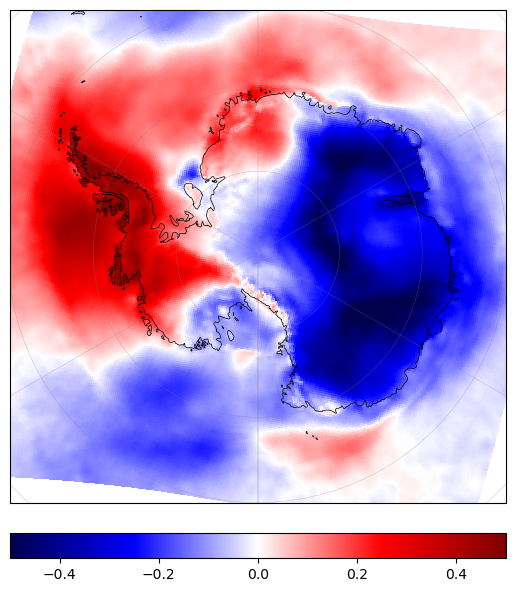

In [11]:
# Define projection
# Use a South Polar Stereographic projection for proper representation of Antarctica.
proj = ccrs.SouthPolarStereo()

# Create figure and axes
# The axes use the stereographic projection defined above.
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Set extent to include entire Antarctic region
# Input coordinates to set_extent must be in PlateCarree (lat/lon) coordinates.
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Plot correlation map
# eais_corr_map is the spatial correlation between each SMB grid cell and EAIS SMB.
# RACMO lon/lat arrays define the spatial coordinates.
im = ax.pcolormesh(
    racmo_accum["lon"], racmo_accum["lat"], slopes_temp,
    transform=ccrs.PlateCarree(), vmin=-0.5, vmax=0.5, cmap=plt.cm.seismic # data defined in geographic coordinates
)

# Add colorbar
cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
#cb.set_label("Correlation with Antarctic-wide SMB (1979–2022)")

# Add geographic features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black")
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

# Add gridlines (no labels for cleaner polar map)
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))

# Add title
#plt.title("Local–Continental SMB Correlation (1979–2022)", fontsize=12, pad=10)

# Render plot
plt.show()


In [12]:
mask = xr.open_dataset(home_path + path + "/TotIS_RACMO_ANT27_IMBIE2.nc")

def compute_2d_bounds(arr):
    """
    Compute approximate 2D cell corner bounds for a 2D array.
    arr: 2D array of lat or lon with shape (ny, nx)
    Returns: 2D array of bounds with shape (ny+1, nx+1)

    This function is used when constructing an xESMF grid, which requires
    cell-corner coordinates rather than cell centers. The bounds are 
    approximated by averaging adjacent grid cells and extrapolating at edges.
    """
    ny, nx = arr.shape

    # Compute interior midpoints (unused in final calculation, but preserves idea)
    b = 0.5 * (arr[:-1, :-1] + arr[1:, 1:])

    # Allocate full bounds array (one larger in each dimension)
    b_full = np.zeros((ny+1, nx+1))

    # Fill interior bounds using 4-cell average (standard finite-difference midpoint)
    b_full[1:-1, 1:-1] = 0.25 * (arr[:-1, :-1] + arr[1:, :-1] + arr[:-1, 1:] + arr[1:, 1:])

    # Top/bottom edges: extrapolate one half-grid outside domain
    b_full[0, 1:-1] = arr[0, :-1] - 0.5 * (arr[1, :-1] - arr[0, :-1])
    b_full[-1, 1:-1] = arr[-1, :-1] + 0.5 * (arr[-1, :-1] - arr[-2, :-1])

    # Left/right edges: similar 1D extrapolation in x
    b_full[1:-1, 0] = arr[:-1, 0] - 0.5 * (arr[:-1, 1] - arr[:-1, 0])
    b_full[1:-1, -1] = arr[:-1, -1] + 0.5 * (arr[:-1, -1] - arr[:-1, -2])

    # Fill corners by copying nearest interior bounds (simple but sufficient)
    b_full[0, 0] = b_full[1, 1]
    b_full[0, -1] = b_full[1, -2]
    b_full[-1, 0] = b_full[-2, 1]
    b_full[-1, -1] = b_full[-2, -2]

    return b_full

# Extract lat/lon from RACMO regridded Antarctic domain (2D arrays of cell centers)
lat = racmo_accum["lat"].values
lon = racmo_accum["lon"].values

# Compute corner bounds needed for conservative regridding in xESMF
lat_b = compute_2d_bounds(lat)
lon_b = compute_2d_bounds(lon)

# Build an xarray dataset describing the grid geometry for xESMF
grid_ds = xr.Dataset(
    {
        "lat": (["y", "x"], lat),
        "lon": (["y", "x"], lon),
        "lat_b": (["y_b", "x_b"], lat_b),
        "lon_b": (["y_b", "x_b"], lon_b),
    }
)

print(grid_ds)

# Compute grid-cell surface area from lat/lon using xESMF utilities (km²)
cellArea = xe.util.cell_area(grid_ds, earth_radius=6371.0)
threshold = 800
# Copy cell-area array so modifications do not affect original
cellArea_fixed = cellArea.copy()

# Smooth cell-area anomalies row-by-row
for i in range(cellArea_fixed.shape[0]):
    # Compute row mean of all cells that are below threshold
    row_mean = cellArea_fixed[i, :].where(cellArea_fixed[i, :] <= threshold).mean()
    # Replace oversized cells with the representative row mean
    cellArea_fixed[i, :] = xr.where(cellArea_fixed[i, :] > threshold, row_mean, cellArea_fixed[i, :])

cellArr = np.array(cellArea_fixed) * 1e6
basin_mask = mask["GroundedIce"]
basin_mask = basin_mask.where(~np.isnan(basin_mask), 0)




<xarray.Dataset> Size: 2MB
Dimensions:  (y: 240, x: 262, y_b: 241, x_b: 263)
Dimensions without coordinates: y, x, y_b, x_b
Data variables:
    lat      (y, x) float64 503kB -46.75 -46.92 -47.09 ... -47.42 -47.24 -47.07
    lon      (y, x) float64 503kB -126.9 -127.1 -127.3 ... 52.84 53.03 53.23
    lat_b    (y_b, x_b) float64 507kB -46.91 -46.67 -46.84 ... -47.17 -47.24
    lon_b    (y_b, x_b) float64 507kB -126.8 -127.0 -127.2 ... 52.69 52.89 53.28


In [13]:
ais_avgs = np.zeros(200)
wais_avgs = np.zeros(200)
eais_avgs = np.zeros(200)
ap_avgs = np.zeros(200)

for i in range(200):
    # Extract the i-th layer
    layer = reshaped_means_temp[i]  # shape: (240, 262)
    
    # Apply the mask
    ais_mask = (basin_mask != 0)  # boolean array, True where you want to include cells
    wais_mask = (
    (basin_mask == 3) |
    ((basin_mask >= 7) & (basin_mask <= 10))
)
    eais_mask = (
    (basin_mask == 1) |
    (basin_mask == 2) |
    ((basin_mask >= 11) & (basin_mask <= 18))
)
    
    ap_mask = (
    (basin_mask == 4) |
    (basin_mask == 5) |
    (basin_mask == 6)
)

    masked_ais = layer[ais_mask]        # only elements where basin_mask != 0
    masked_weights_ais = cellArr[ais_mask]  # corresponding weights

    masked_wais = layer[wais_mask]        # only elements where basin_mask != 0
    masked_weights_wais = cellArr[wais_mask]  # corresponding weights
    masked_eais = layer[eais_mask]        # only elements where basin_mask != 0
    masked_weights_eais = cellArr[eais_mask]  # corresponding weights
    masked_ap = layer[ap_mask]        # only elements where basin_mask != 0
    masked_weights_ap = cellArr[ap_mask]  # corresponding weights
    
    # Compute weighted average
    ais_avgs[i] = np.average(masked_ais, weights=masked_weights_ais)
    wais_avgs[i] = np.average(masked_wais, weights=masked_weights_wais)
    eais_avgs[i] = np.average(masked_eais, weights=masked_weights_eais)
    ap_avgs[i] = np.average(masked_ap, weights=masked_weights_ap)   

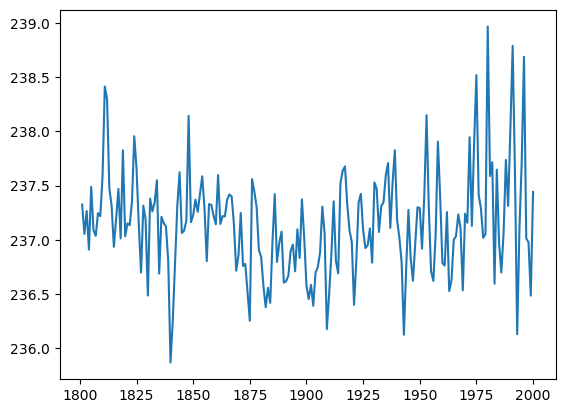

In [14]:
plt.plot(np.arange(1801, 2001), ais_avgs)

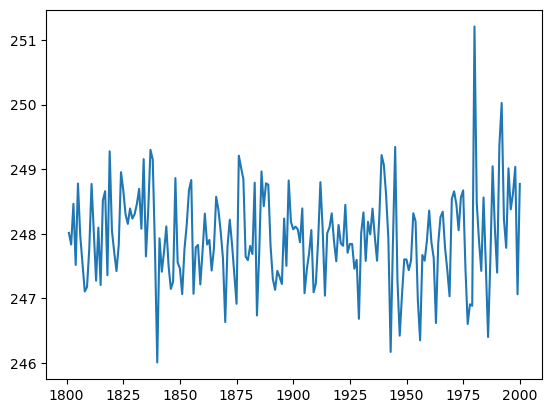

In [15]:
plt.plot(np.arange(1801, 2001), wais_avgs)

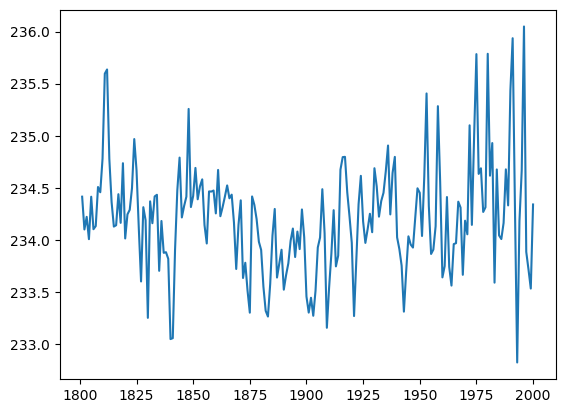

In [16]:
plt.plot(np.arange(1801, 2001), eais_avgs)

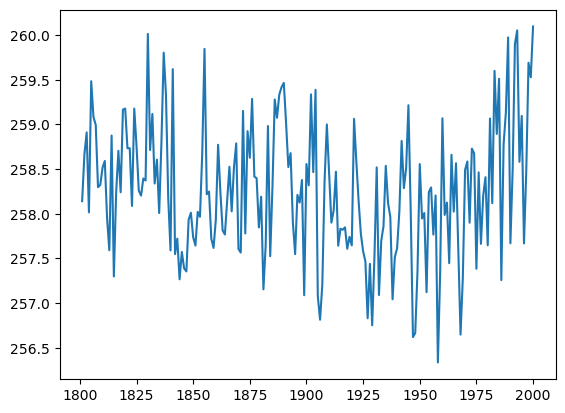

In [17]:
plt.plot(np.arange(1801, 2001), ap_avgs)

In [18]:
smb_ann = (
    racmo_accum["smb"]
    .squeeze("height")
    .groupby("time.year")
    .sum(dim="time")
    .sel(year=slice(1979, 2022))
)

# Preallocate arrays for core-to-RACMO statistical relationships
temp_site_slope = np.zeros(len(core_lats))       # regression slope
temp_site_intercept = np.zeros(len(core_lats))   # regression intercept

# Observation-error covariance matrix (diagonal) for 164 cores
R = np.zeros((164, 164))

# Arrays to store RACMO annual SMB values at each accum core location (first 42 years)
accum_points = np.zeros((84, 42))
temp_points = np.zeros((80, 42))

# Bias-corrected RACMO values aligned with each core (ensemble observation operator)
y_e = np.zeros((164, 42))

# Loop through each accum ice core and compute grid-point match + regression statistics
for i in range(84):
    # Target core latitude/longitude
    target_lat = core_lats[i]
    target_lon = core_lons[i]

    # Convert longitudes to 0–360 domain
    target_lon = (target_lon + 360) % 360
    lon2d = (smb_ann['lon'].values + 360) % 360
    lat2d = smb_ann['lat'].values

    # Compute squared distance on the lat-lon grid to find nearest RACMO point
    dist2 = (lat2d - target_lat)**2 + (lon2d - target_lon)**2
    j, k = np.unravel_index(np.argmin(dist2), dist2.shape)

    # Extract RACMO annual SMB time series for nearest grid cell (first 42 years)
    smb_point = smb_ann[:42].isel(rlat=j, rlon=k)

    # Extract observed accumulation record for this core (42 yrs, 1979–2020 subset)
    obs = accumCores[i, :]

    # Identify valid (non-NaN) overlapping years
    valid = np.isfinite(obs) & np.isfinite(smb_point)
    valid_idx = np.where(valid)[0]

    # Valid subsets for regression and correlation
    smb_valid = smb_point[valid_idx]
    obs_valid = obs[valid_idx]

    # Store uncorrected RACMO values
    accum_points[i, :] = smb_point

    # Prepare regression inputs (column vectors)
    x = np.array(smb_point[valid]).reshape(-1, 1)
    y = np.array(obs[valid]).reshape(-1, 1)

    # Linear regression of obs ~ SMB
    reg = LinearRegression().fit(x, y)
    slope = reg.coef_[0][0]
    intercept = reg.intercept_[0]

    # Predicted values from regression
    y_pred = reg.predict(x)

    # Error variance (to populate diagonal of R)
    error_var = np.var(y - y_pred, ddof=1)
    R[i, i] = error_var

# loop through water isotope cores
for i in range(80):
     # Target core latitude/longitude
    target_lat = water_lats[i]
    target_lon = water_lons[i]

    # Convert longitudes to 0–360 domain
    target_lon = (target_lon + 360) % 360
    lon2d = (smb_ann['lon'].values + 360) % 360
    lat2d = smb_ann['lat'].values

    # Compute squared distance on the lat-lon grid to find nearest RACMO point
    dist2 = (lat2d - target_lat)**2 + (lon2d - target_lon)**2
    j, k = np.unravel_index(np.argmin(dist2), dist2.shape)

    # Extract RACMO annual Temp time series for nearest grid cell (first 42 years)
    temp_point = temp_ann[:42].isel(rlat=j, rlon=k)

    # Extract observed water isotope record for this core (42 yrs, 1979–2020 subset)
    obs = waterCores[i, :]

    # Identify valid (non-NaN) overlapping years
    valid = np.isfinite(obs) & np.isfinite(temp_point)
    valid_idx = np.where(valid)[0]

    # Valid subsets for regression and correlation
    temp_valid = temp_point[valid_idx]
    obs_valid = obs[valid_idx]

    # Store uncorrected RACMO values
    temp_points[i, :] = temp_point

    # Prepare regression inputs (column vectors)
    x = np.array(temp_point[valid]).reshape(-1, 1)
    y = np.array(obs[valid]).reshape(-1, 1)

    # Linear regression of obs ~ SMB
    reg = LinearRegression().fit(x, y)
    slope = reg.coef_[0][0]
    intercept = reg.intercept_[0]

    temp_site_slope[i] = slope
    temp_site_intercept[i] = intercept

    # Predicted values from regression
    y_pred = reg.predict(x)

    # Error variance (to populate diagonal of R)
    error_var = np.var(y - y_pred, ddof=1)
    R[i+84, i+84] = error_var


# Mask for valid values when computing means across time
mask = np.isfinite(accum_points) & np.isfinite(accumCores)

# Compute RACMO mean and proxy mean at each accumulation core, only over shared valid years
racmo_mean = np.nanmean(accum_points, axis=1, where=mask)
proxy_mean = np.nanmean(accumCores, axis=1, where=mask)

# Mean offset = proxy minus model → used for bias correction
mean_offset = proxy_mean - racmo_mean

print(mean_offset.shape)

# Bias-correct the RACMO time series for each accum core by adding the mean offset
for i in range(84):
    y_e[i, :] = accum_points[i, :] + mean_offset[i]

# Use the linear regression PSM for water isotope cores temperature estimate
for i in range(80):
    y_e[i+84, :] = temp_points[i, :] * temp_site_slope[i] + temp_site_intercept[i]

(84,)


In [19]:
smb_cells = smb_ann.values.reshape(smb_ann.shape[0], -1)

posterior_mean = np.zeros((200, 62880), dtype=np.float32)
posterior_std  = np.zeros((200, 62880), dtype=np.float32)

for i in range(200):

    # ---- initialize prior ----
    X_mean = smb_cells[:42].mean(axis=0)            # (Ns,)
    X_dev  = smb_cells[:42] - X_mean                # (Ne, Ns)

    # ---- sequential proxy assimilation ----
    for j in range(164):

        # ===============================
        # ACCUMULATION CORES
        # ===============================
        if j < 84 and not np.isnan(accumCoresFull[i, j]):

            y_obs = accumCoresFull[i, j]

        # ===============================
        # ISOTOPE CORES
        # ===============================
        elif j >= 84 and not np.isnan(waterCoresFull[i, j - 84]):

            y_obs = waterCoresFull[i, j - 84]

        else:
            continue

        # ---- predicted obs stats ----
        y_mean = y_e[j, :].mean()
        y_dev  = y_e[j, :] - y_mean
        y_var  = np.var(y_e[j, :], ddof=1)

        # ---- state–obs covariance ----
        cov_xy = (X_dev.T @ y_dev) / (42 - 1)    # (Ns,)

        # ---- Kalman gain ----
        K = cov_xy / (y_var + R[j, j])            # (Ns,)

        # ---- mean update ----
        X_mean += K * (y_obs - y_mean)

        # ---- EnSRF square-root factor ----
        alpha = 1.0 / (1.0 + np.sqrt(R[j, j] / (y_var + R[j, j])))

        # ---- deviation update ----
        X_dev -= alpha * np.outer(y_dev, K)     # (Ne, Ns)

    # ---- save AIS-wide reconstruction ----
    posterior_mean[i, :] = X_mean
    posterior_std[i, :]  = X_dev.std(axis=0, ddof=1)


In [20]:
reshaped_means_accum = posterior_mean.reshape(200, 240, 262)

In [21]:
import numpy as np

start_idx = 1801 - 1801  # 156
end_idx   = 2000 - 1801  # 199

subset = reshaped_means_accum[start_idx:end_idx+1, :, :]  # shape (44, 242, 262)

years_subset = np.arange(subset.shape[0])  # 0..43 for 44 years

nlat, nlon = subset.shape[1:]
Y = subset.reshape(subset.shape[0], -1)  # shape (44, ngrid)

# Design matrix for linear regression: [time, intercept]
X = np.vstack([years_subset, np.ones_like(years_subset)]).T  # shape (44,2)

# Solve least squares for all grid cells
beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)

slopes_accum = beta[0].reshape(nlat, nlon) * 10    # trend per grid cell
intercepts = beta[1].reshape(nlat, nlon)   # intercept per grid cell



/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


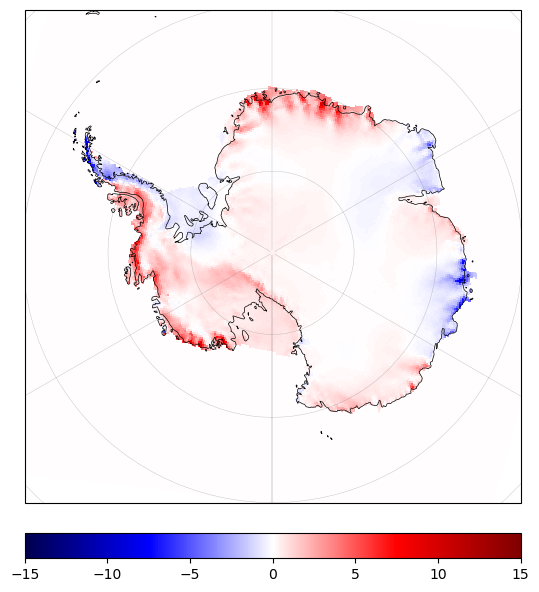

In [22]:
# Define projection
# Use a South Polar Stereographic projection for proper representation of Antarctica.
proj = ccrs.SouthPolarStereo()

# Create figure and axes
# The axes use the stereographic projection defined above.
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Set extent to include entire Antarctic region
# Input coordinates to set_extent must be in PlateCarree (lat/lon) coordinates.
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Plot correlation map
# eais_corr_map is the spatial correlation between each SMB grid cell and EAIS SMB.
# RACMO lon/lat arrays define the spatial coordinates.
im = ax.pcolormesh(
    racmo_accum["lon"], racmo_accum["lat"], slopes_accum,
    transform=ccrs.PlateCarree(), vmin=-15, vmax=15, cmap=plt.cm.seismic # data defined in geographic coordinates
)

# Add colorbar
cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
#cb.set_label("Correlation with Antarctic-wide SMB (1979–2022)")

# Add geographic features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black")
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

# Add gridlines (no labels for cleaner polar map)
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))

# Add title
#plt.title("Local–Continental SMB Correlation (1979–2022)", fontsize=12, pad=10)

# Render plot
plt.show()


In [23]:
flat_temps = reshaped_means_temp[:, 100, 100].ravel()
flat_accum = reshaped_means_accum[:, 100, 100].ravel()

In [24]:
T = reshaped_means_temp
P = reshaped_means_accum

# Remove time means
T_anom = T - T.mean(axis=0)
P_anom = P - P.mean(axis=0)

# Regression slope dP/dT
dP_dT = np.sum(T_anom * P_anom, axis=0) / np.sum(T_anom**2, axis=0)

In [25]:
P_mean = P.mean(axis=0)

sensitivity_percent_per_K = 100.0 * dP_dT / P_mean
mask = P_mean > 0
sensitivity = np.where(mask, sensitivity_percent_per_K, np.nan)



In [26]:


# Log-scale the accumulation (only where positive)
log_P = np.where(P > 0, np.log(P), np.nan)

# Anomalies
T_anom = T - np.nanmean(T, axis=0)
logP_anom = log_P - np.nanmean(log_P, axis=0)

# Regression slope d(ln P)/dT — this directly gives % per K when multiplied by 100
d_lnP_dT = np.nansum(T_anom * logP_anom, axis=0) / np.nansum(T_anom**2, axis=0)
sensitivity_log = 100.0 * d_lnP_dT  # % per K

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_2075/845159601.py:2: RuntimeWarning: invalid value encountered in log
  log_P = np.where(P > 0, np.log(P), np.nan)


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


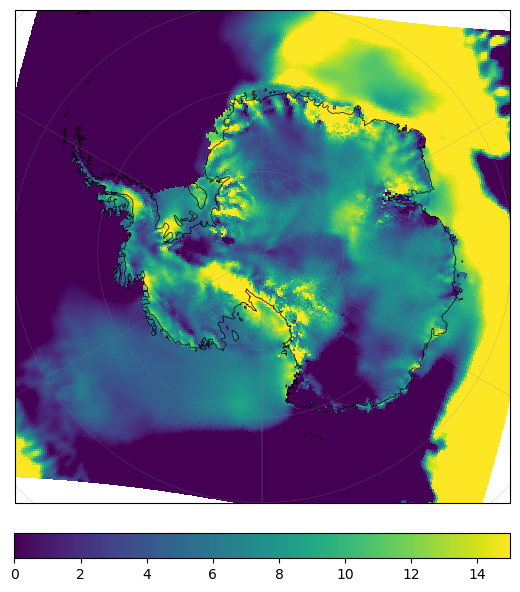

In [33]:
# Define projection
# Use a South Polar Stereographic projection for proper representation of Antarctica.
proj = ccrs.SouthPolarStereo()

# Create figure and axes
# The axes use the stereographic projection defined above.
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Set extent to include entire Antarctic region
# Input coordinates to set_extent must be in PlateCarree (lat/lon) coordinates.
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Plot correlation map
# eais_corr_map is the spatial correlation between each SMB grid cell and EAIS SMB.
# RACMO lon/lat arrays define the spatial coordinates.
im = ax.pcolormesh(
    racmo_accum["lon"], racmo_accum["lat"], sensitivity_log,
    transform=ccrs.PlateCarree(), vmin=0, vmax=15, #cmap=plt.cm.seismic# data defined in geographic coordinates
)

# Add colorbar
cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
#cb.set_label("Correlation with Antarctic-wide SMB (1979–2022)")

# Add geographic features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black")
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

# Add gridlines (no labels for cleaner polar map)
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))

# Add title
#plt.title("Local–Continental SMB Correlation (1979–2022)", fontsize=12, pad=10)

# Render plot
plt.show()


In [31]:
T = temp_ann
P = smb_ann

# Remove time means
T_anom = T - T.mean(axis=0)
P_anom = P - P.mean(axis=0)

# Regression slope dP/dT
dP_dT = np.sum(T_anom * P_anom, axis=0) / np.sum(T_anom**2, axis=0)

P_mean = P.mean(axis=0)

sensitivity_percent_per_K = 100.0 * dP_dT / P_mean
mask = P_mean > 0
sensitivity = np.where(mask, sensitivity_percent_per_K, np.nan)



/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


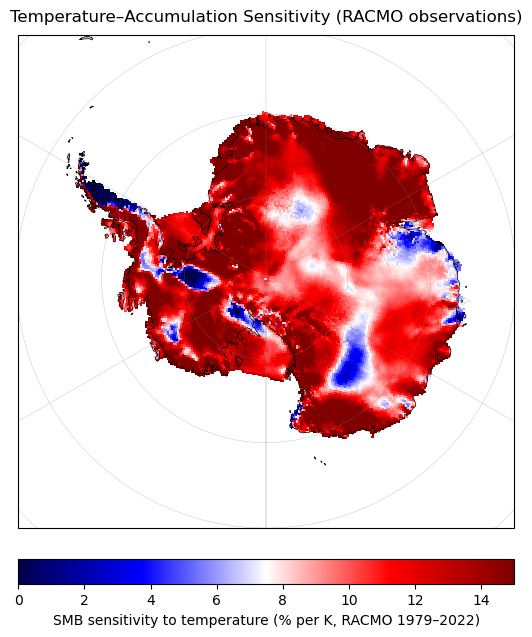

In [32]:
# Plot
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

im = ax.pcolormesh(
    racmo_accum["lon"], racmo_accum["lat"], sensitivity,
    transform=ccrs.PlateCarree(), vmin=0, vmax=15, cmap=plt.cm.seismic
)

cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cb.set_label("SMB sensitivity to temperature (% per K, RACMO 1979–2022)")

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black")
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))

plt.title("Temperature–Accumulation Sensitivity (RACMO observations)", fontsize=12, pad=10)
plt.show()

In [29]:


# Log-scale the accumulation (only where positive)
log_P = np.where(P_obs > 0, np.log(P_obs), np.nan)

# Anomalies
T_anom = T_obs - np.nanmean(T_obs, axis=0)
logP_anom = log_P - np.nanmean(log_P, axis=0)

# Regression slope d(ln P)/dT — this directly gives % per K when multiplied by 100
d_lnP_dT = np.nansum(T_anom * logP_anom, axis=0) / np.nansum(T_anom**2, axis=0)
sensitivity_log = 100.0 * d_lnP_dT  # % per K

NameError: name 'P_obs' is not defined

In [ ]:


start_idx = 1979 - 1979  # 156
end_idx   = 2000 - 1979  # 199

subset = temp_ann.values[start_idx:end_idx+1, :, :]  # shape (44, 242, 262)

years_subset = np.arange(subset.shape[0])  # 0..43 for 44 years

nlat, nlon = subset.shape[1:]
Y = subset.reshape(subset.shape[0], -1)  # shape (44, ngrid)

# Design matrix for linear regression: [time, intercept]
X = np.vstack([years_subset, np.ones_like(years_subset)]).T  # shape (44,2)

# Solve least squares for all grid cells
beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)

racmo_slopes = beta[0].reshape(nlat, nlon) * 10    # trend per grid cell
intercepts = beta[1].reshape(nlat, nlon)   # intercept per grid cell



/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


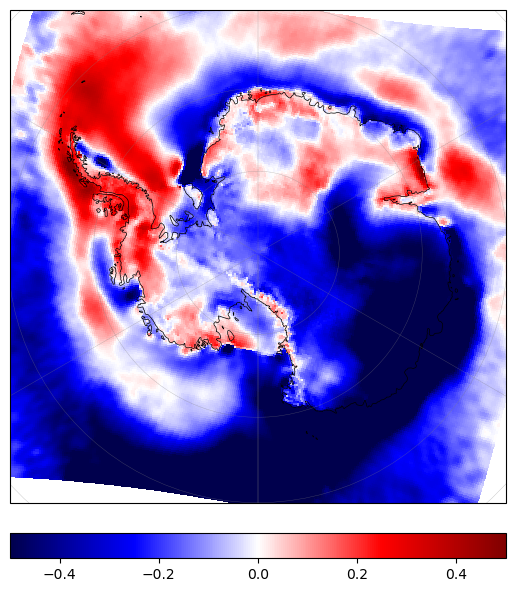

In [ ]:
# Define projection
# Use a South Polar Stereographic projection for proper representation of Antarctica.
proj = ccrs.SouthPolarStereo()

# Create figure and axes
# The axes use the stereographic projection defined above.
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Set extent to include entire Antarctic region
# Input coordinates to set_extent must be in PlateCarree (lat/lon) coordinates.
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

# Plot correlation map
# eais_corr_map is the spatial correlation between each SMB grid cell and EAIS SMB.
# RACMO lon/lat arrays define the spatial coordinates.
im = ax.pcolormesh(
    racmo_accum["lon"], racmo_accum["lat"], racmo_slopes,
    transform=ccrs.PlateCarree(), vmin=-0.5, vmax=0.5, cmap=plt.cm.seismic# data defined in geographic coordinates
)

# Add colorbar
cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
#cb.set_label("Correlation with Antarctic-wide SMB (1979–2022)")

# Add geographic features for context
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black")
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

# Add gridlines (no labels for cleaner polar map)
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))

# Add title
#plt.title("Local–Continental SMB Correlation (1979–2022)", fontsize=12, pad=10)

# Render plot
plt.show()


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


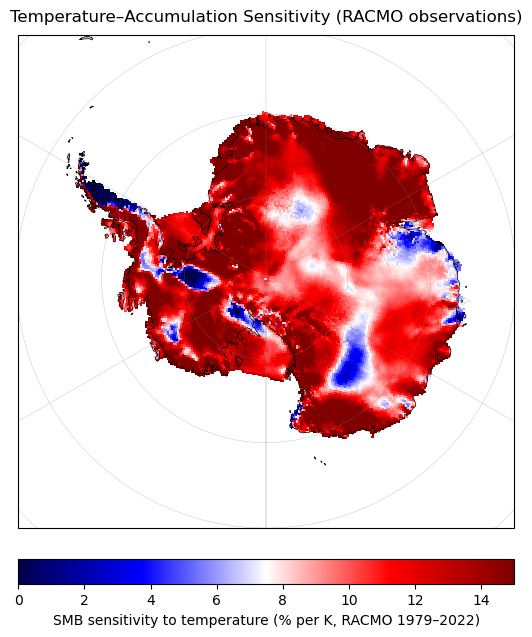

In [ ]:
T_obs = temp_ann.values  # shape (44, 240, 262)
P_obs = smb_ann.values   # shape (44, 240, 262)

# Remove time means
T_anom = T_obs - T_obs.mean(axis=0)
P_anom = P_obs - P_obs.mean(axis=0)

# Regression slope dP/dT
dP_dT_obs = np.sum(T_anom * P_anom, axis=0) / np.sum(T_anom**2, axis=0)

# Convert to % per K
P_mean_obs = P_obs.mean(axis=0)
mask_obs = P_mean_obs > 0
sensitivity_obs = np.where(mask_obs, 100.0 * dP_dT_obs / P_mean_obs, np.nan)

# Plot
proj = ccrs.SouthPolarStereo()
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

im = ax.pcolormesh(
    racmo_accum["lon"], racmo_accum["lat"], sensitivity_obs,
    transform=ccrs.PlateCarree(), vmin=0, vmax=15, cmap=plt.cm.seismic
)

cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.8)
cb.set_label("SMB sensitivity to temperature (% per K, RACMO 1979–2022)")

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="black")
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
gl = ax.gridlines(draw_labels=False, linewidth=0.3, color="gray", alpha=0.5)
gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))

plt.title("Temperature–Accumulation Sensitivity (RACMO observations)", fontsize=12, pad=10)
plt.show()